In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [17]:
df = pd.read_parquet(DATA_FOLDER / "pandas_full_2019.parquet")

In [18]:
df['start_day'] = df['starttime'].dt.day_name()
df['hour'] = df['starttime'].dt.hour


In [19]:
# Yearly variations
df['day_of_year'] = df['starttime'].dt.dayofyear
df['date'] = df['starttime'].dt.date
trips_per_day = df.groupby(by=['day_of_year']).agg(
    count_trips = pd.NamedAgg(column='tripduration', aggfunc='count'),
    weekday = pd.NamedAgg(column='start_day', aggfunc=lambda x: pd.Series.mode(x)[0]),
    DATE = pd.NamedAgg(column='date', aggfunc=lambda x: pd.Series.mode(x)[0]))

trips_per_day["DATE"] = trips_per_day["DATE"].astype(str)
display(trips_per_day.dtypes, trips_per_day.head(4))

count_trips     int64
weekday        object
DATE           object
dtype: object

,count_trips,weekday,DATE
day_of_year,,,
1,21962,Tuesday,2019-01-01
2,37797,Wednesday,2019-01-02
3,41676,Thursday,2019-01-03
4,43922,Friday,2019-01-04


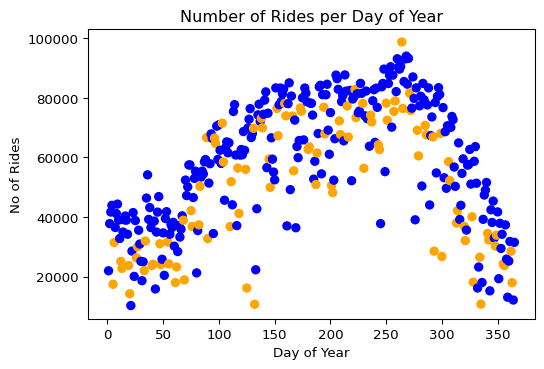

In [20]:
weekend_col = {'Monday':'blue','Tuesday':'blue', 'Wednesday':'blue', 'Thursday':'blue', 'Friday':'blue', 'Saturday':'orange', 'Sunday':'orange'}

plt.figure(dpi=96)
plt.scatter(trips_per_day.index, trips_per_day.count_trips, color=trips_per_day.weekday.map(weekend_col))
plt.title('Number of Rides per Day of Year')
plt.xlabel('Day of Year')
plt.ylabel('No of Rides')
plt.show()

In [21]:
# Get weather data and join with daily riders
ghcn = pd.read_csv('data/weather/2019_clean.csv')
ghcn = ghcn.drop(columns=['Unnamed: 0'])
ghcn['DATE'] = ghcn['DATE'].astype(str)
#display(ghcn.dtypes, ghcn.head(5))

In [22]:
trips_per_day = pd.merge(trips_per_day, ghcn, how="left", on='DATE')
print(trips_per_day.dtypes)
display(trips_per_day.head(5))

count_trips      int64
weekday         object
DATE            object
AWND           float64
PRCP           float64
SNOW           float64
SNWD           float64
TMAX           float64
TMIN           float64
fog              int64
heavy_fog        int64
sleet            int64
haze             int64
fsh              int64
dtype: object


,count_trips,weekday,DATE,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,fog,heavy_fog,sleet,haze,fsh
0,21962,Tuesday,2019-01-01,0.0,0.06,0.0,0.0,14.4,3.9,1,0,0,0,1
1,37797,Wednesday,2019-01-02,0.0,0.00,0.0,0.0,4.4,1.7,0,0,0,0,0
2,41676,Thursday,2019-01-03,0.0,0.00,0.0,0.0,6.7,2.8,0,0,0,0,0
3,43922,Friday,2019-01-04,0.0,0.00,0.0,0.0,8.3,1.7,0,0,0,0,0
4,17432,Saturday,2019-01-05,0.0,0.50,0.0,0.0,8.3,5.0,1,0,0,0,1


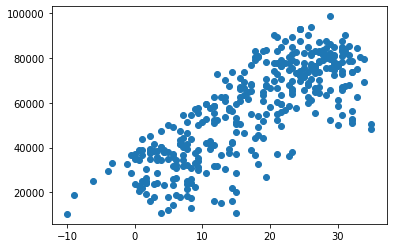

In [23]:
plt.figure()
plt.scatter(trips_per_day.TMAX, trips_per_day.count_trips)
plt.show()

In [34]:
X = trips_per_day[['TMAX','PRCP', 'AWND', 'fsh']]
X['TxPrcp'] = X["TMAX"] * X['PRCP']
X['TxAwnd'] = X["TMAX"] * X['AWND']
X['AWNDxPrcp'] = X["AWND"] * X['PRCP']
X['TxPrcpxAwnd'] = X["TMAX"] * X['PRCP'] * X['AWND']
y = trips_per_day[['count_trips']].to_numpy() #.reshape(-1,1)
display(X.head(3))

,TMAX,PRCP,AWND,fsh,TxPrcp,TxAwnd,AWNDxPrcp,TxPrcpxAwnd
0,14.4,0.06,0.0,1,0.864,0.0,0.0,0.0
1,4.4,0.00,0.0,0,0.000,0.0,0.0,0.0
2,6.7,0.00,0.0,0,0.000,0.0,0.0,0.0


In [70]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,y, test_size=0.2, shuffle=True)

num_list = ['TMAX','PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd']
pass_list = ['fsh']
preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])
pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])
pipe.fit(Xtrain,ytrain)
y_pred = pipe.predict(Xtest)
r2_score_ = r2_score(ytest, y_pred)
print(f'{num_list}, r2 score: {r2_score_:.2f}')
score = cross_val_score(pipe, Xtrain, ytrain, cv=10)
print(f'mean:{np.mean(score):.2f}, std:{np.std(score):.2f}')

num_list = ['TMAX', 'PRCP'] #, 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd']
pass_list = ['fsh'] #['fsh']
preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])
pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])
pipe.fit(Xtrain[num_list+pass_list],ytrain)
y_pred = pipe.predict(Xtest[num_list+pass_list])
r2_score_ = r2_score(ytest, y_pred)
print(f'{num_list}, r2 score: {r2_score_:.2f}')
score = cross_val_score(pipe, Xtrain, ytrain, cv=10)
print(f'mean:{np.mean(score):.2f}, std:{np.std(score):.2f}')

num_list = ['TMAX', 'PRCP', 'TxPrcp'] #, 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd']
pass_list = [] #['fsh']
preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])
pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])
pipe.fit(Xtrain[num_list],ytrain)
y_pred = pipe.predict(Xtest[num_list])
r2_score_ = r2_score(ytest, y_pred)
print(f'{num_list}, r2 score: {r2_score_:.2f}')
score = cross_val_score(pipe, Xtrain, ytrain, cv=10)
print(f'mean:{np.mean(score):.2f}, std:{np.std(score):.2f}')



['TMAX', 'PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd'], r2 score: 0.70
mean:0.72, std:0.10
['TMAX', 'PRCP'], r2 score: 0.71
mean:0.72, std:0.10
['TMAX', 'PRCP', 'TxPrcp'], r2 score: 0.71
mean:0.72, std:0.09


In [86]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,y, test_size=0.2, shuffle=True)

def var_test(num_list, pass_list):
    preprocessor = ColumnTransformer(
        transformers=[('nums', StandardScaler(), num_list), 
                    ('pass','passthrough', pass_list)])
    pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])
    pipe.fit(Xtrain,ytrain)
    y_pred = pipe.predict(Xtest)
    r2_score_ = r2_score(ytest, y_pred)
    print(f'{num_list}, r2 score: {r2_score_:.2f}')
    score = cross_val_score(pipe, Xtrain, ytrain, cv=10)
    print(f'mean:{np.mean(score):.2f}, std:{np.std(score):.2f}')

num_list = ['TMAX','PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd']
pass_list = ['fsh']
var_test(num_list, pass_list)

num_list = ['TMAX','PRCP']
pass_list = []
var_test(num_list, pass_list)

num_list = ['TMAX','PRCP', 'TxPrcp']
pass_list = ['fsh']
var_test(num_list, pass_list)

['TMAX', 'PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd'], r2 score: 0.63
mean:0.74, std:0.03
['TMAX', 'PRCP'], r2 score: 0.62
mean:0.74, std:0.04
['TMAX', 'PRCP', 'TxPrcp'], r2 score: 0.63
mean:0.75, std:0.03


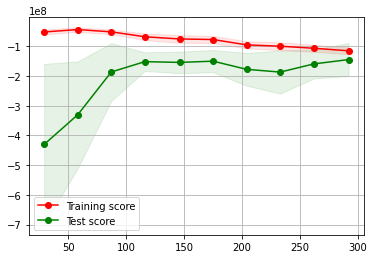

In [90]:
from sklearn.model_selection import learning_curve

def plt_learning_curve(train_scores_mean, train_scores_std, test_scores_mean, \
    test_scores_std):
    plt.figure()

    plt.fill_between(train_sizes, train_scores_mean + train_scores_std,
                    train_scores_mean - train_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_scores_mean + test_scores_std,
                    test_scores_mean - test_scores_std, alpha=0.1, color='g')

    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test score')

    plt.legend()
    plt.grid()
    plt.show

    return

Xtrain, Xtest, ytrain, ytest = train_test_split(X,y, test_size=0.2, shuffle=True)
num_list = ['TMAX','PRCP', 'TxPrcp']
pass_list = ['fsh']
preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])
pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])
pipe.fit(Xtrain,ytrain)

train_sizes, train_scores, test_scores = learning_curve(
        pipe, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1., 10),scoring="neg_mean_squared_error", verbose=0)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt_learning_curve(train_scores_mean, train_scores_std, test_scores_mean, test_scores_std)


In [77]:
num_list = [] #['TMAX','PRCP', 'AWND', 'TxPrcp', 'TxAwnd', 'WNDxPrcp', 'TxPrcpxAwnd']
pass_list = [] #['fsh']

preprocessor = ColumnTransformer(
    transformers=[('nums', StandardScaler(), num_list), 
                ('pass','passthrough', pass_list)])

pipe = Pipeline(steps=[('preprocessor',preprocessor),('lin_reg',LinearRegression())])

#Xtrain_norm = pipe.fit_transform(Xtrain)
#reg = LinearRegression().fit(Xtrain_norm,ytrain)

var_list = ['TMAX','PRCP', 'fsh', 'AWND', 'TxPrcp', 'TxAwnd', 'AWNDxPrcp', 'TxPrcpxAwnd']
test_results = []
for var in var_list:
    if var == 'fsh': 
        pass_list.append(var)
    else: 
        num_list.append(var)
        
    a_list = []
    for i in range(10):
        Xtrain, Xtest, ytrain, ytest = train_test_split(X[num_list+pass_list],y, test_size=0.2, shuffle=True)
        
        pipe.fit(Xtrain,ytrain)

        #print(pipe.feature_names_in_)

        #pipe.transform(Xtest)
        #Xtest_norm = pipe.transform(Xtest)

        y_pred = pipe.predict(Xtest)
        #rmse = np.sqrt(mean_squared_error(ytest, y_pred))
        r2_score_ = r2_score(ytest, y_pred)
        a_list.append(r2_score_)

    #for i in range(5):
    #    print(a_list[i])
    
    print(f'mean:{np.mean(a_list):.2f}, std:{np.std(a_list):.2f}')
#print(f"mean error:{round(np.sqrt(mean_2_err),2)}, r2 score:{round(r2_score_,2)}")
   

['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
['TMAX']
mean:0.62, std:0.06
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
['TMAX' 'PRCP']
mean:0.73, std:0.05
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
['TMAX' 'PRCP' 'fsh']
mean:0.74, std:0.06
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
['TMAX' 'PRCP' 'AWND' 'fsh']
mean:0.71, std:0.10
['TMAX' 'PRCP' 'AWND' 'TxPrcp' 'fsh']
['TMAX' 'PRCP' 'AWND' 'TxPrcp' 'fsh']
['TMAX' 'PRCP' 'AWND' 'TxPrcp' 'fsh']
['TMAX' 'PRCP' 'AWND' 'TxPrcp' 'fsh']
['TMAX' 

KeyError: "['WNDxPrcp'] not in index"